# IEMOCAP Provided-Transcript + DistilBERT Pipeline

This notebook uses the transcriptions already present in the dataset instead of running ASR.

Pipeline:
- provided IEMOCAP transcription
- DistilBERT embeddings with mean/std/max/min pooling
- MLP emotion classifier

## Imports

In [2]:
import ctypes
import os
import warnings

prefix = os.environ.get("CONDA_PREFIX")
if prefix:
    ctypes.CDLL(f"{prefix}/lib/libgcc_s.so.1", mode=ctypes.RTLD_GLOBAL)
    ctypes.CDLL(f"{prefix}/lib/libstdc++.so.6", mode=ctypes.RTLD_GLOBAL)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
from transformers import AutoModel, AutoTokenizer

from iemocap_pipeline_utils import (
    EmotionClassifier,
    build_iemocap_metadata,
    build_label_maps,
    compute_class_weights,
    create_dataloaders,
    embed_texts_with_distilbert,
    encode_labels,
    filter_iemocap_metadata,
    load_iemocap_train_split,
    scale_train_test,
    session_holdout_split,
    train_model,
    evaluate_model,
)

warnings.filterwarnings("ignore")
np.random.seed(42)
torch.manual_seed(42)

## Configuration

In [3]:
DATASET_ID = "AbstractTTS/IEMOCAP"
LABEL_COLUMN = "major_emotion"
DROP_LABELS = {"other"}
MIN_SAMPLES_PER_CLASS = 30
TEST_SESSIONS = ("Ses05",)
MAX_SAMPLES = None  # Set an int for quicker experiments.

TEXT_MODEL_NAME = "distilbert-base-uncased"
BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
DROPOUT = 0.5

CACHE_DIR = "IEMOCAP_cache"
TEXT_EMBEDDING_CACHE_PATH = os.path.join(CACHE_DIR, "provided_transcript_distilbert_embeddings.npz")
CHECKPOINT_PATH = os.path.join("models", "IEMOCAP_transcript_distilbert.pth")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load And Filter IEMOCAP

In [4]:
iemocap_dataset = load_iemocap_train_split(DATASET_ID)
metadata = build_iemocap_metadata(iemocap_dataset)
filtered_metadata, label_counts = filter_iemocap_metadata(
    metadata,
    label_column=LABEL_COLUMN,
    drop_labels=DROP_LABELS,
    min_samples_per_class=MIN_SAMPLES_PER_CLASS,
    max_samples=MAX_SAMPLES,
)

texts = filtered_metadata["transcription"].fillna("").astype(str).str.strip().tolist()
print(f"Original samples: {len(metadata)}")
print(f"Filtered samples: {len(filtered_metadata)}")
label_counts

Original samples: 10039
Filtered samples: 10011


major_emotion
frustrated    2917
excited       1976
neutral       1726
angry         1269
sad           1250
happy          656
surprise       110
fear           107
Name: count, dtype: int64

In [5]:
preview = filtered_metadata[["file", LABEL_COLUMN, "transcription"]].copy()
preview.head()

,file,major_emotion,transcription
0,Ses01F_impro01_F000.wav,neutral,Excuse me.
1,Ses01F_impro01_F001.wav,neutral,Yeah.
2,Ses01F_impro01_F002.wav,neutral,Is there a problem?
3,Ses01F_impro01_F003.wav,neutral,You did.
4,Ses01F_impro01_F004.wav,neutral,You were standing at the beginning and you di...


## DistilBERT Embeddings

In [6]:
print(f"Loading text model: {TEXT_MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_NAME)
bert_model = AutoModel.from_pretrained(TEXT_MODEL_NAME).to(device)
bert_model.eval()

Loading text model: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSelfAttention(
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

In [7]:
X = embed_texts_with_distilbert(
    texts,
    tokenizer,
    bert_model,
    device,
    cache_path=TEXT_EMBEDDING_CACHE_PATH,
)
X.shape

Embedding texts: 100%|██████████| 626/626 [00:09<00:00, 66.64it/s]


Saved text embeddings to IEMOCAP_cache/provided_transcript_distilbert_embeddings.npz


(10011, 3072)

## Prepare Session Holdout Split

In [8]:
label_names, label_to_idx, idx_to_label = build_label_maps(filtered_metadata[LABEL_COLUMN])
y = encode_labels(filtered_metadata[LABEL_COLUMN], label_to_idx)

train_mask, test_mask = session_holdout_split(filtered_metadata, test_sessions=TEST_SESSIONS)

train_metadata = filtered_metadata.loc[train_mask].reset_index(drop=True)
test_metadata = filtered_metadata.loc[test_mask].reset_index(drop=True)

X_train_raw = X[train_mask]
X_test_raw = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

X_train, X_test, scaler = scale_train_test(X_train_raw, X_test_raw)
train_loader, test_loader = create_dataloaders(X_train, y_train, X_test, y_test, batch_size=BATCH_SIZE)
class_weights, class_counts = compute_class_weights(y_train, num_classes=len(label_names))

print(f"Train sessions: {sorted(train_metadata['session_id'].unique())}")
print(f"Test sessions: {sorted(test_metadata['session_id'].unique())}")
pd.Series(class_counts, index=label_names, name="train_count")

Train sessions: ['Ses01', 'Ses02', 'Ses03', 'Ses04']
Test sessions: ['Ses05']


angry         1072
excited       1517
fear            77
frustrated    2306
happy          502
neutral       1340
sad            939
surprise        91
Name: train_count, dtype: int64

## Train Classifier

In [9]:
model = EmotionClassifier(
    input_size=X_train.shape[1],
    num_emotions=len(label_names),
    dropout_rate=DROPOUT,
).to(device)

history = train_model(
    model,
    train_loader,
    test_loader,
    device,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    class_weights=class_weights,
)
history

Training on cuda...


Training:   3%|▎         | 1/30 [00:00<00:17,  1.64it/s]

Epoch [1/30] train_loss=2.0077 train_acc=22.11% test_loss=1.7587 test_acc=29.58%


Training:  17%|█▋        | 5/30 [00:02<00:11,  2.11it/s]

Epoch [5/30] train_loss=1.4815 train_acc=33.43% test_loss=1.5964 test_acc=32.72%


...

Training:  83%|████████▎ | 25/30 [00:12<00:02,  2.00it/s]

Epoch [25/30] train_loss=0.9869 train_acc=51.42% test_loss=1.8533 test_acc=37.79%


Training: 100%|██████████| 30/30 [00:14<00:00,  2.04it/s]

Epoch [30/30] train_loss=0.9264 train_acc=53.25% test_loss=1.8535 test_acc=39.55%


{'train_loss': [2.0077489910086963,
  1.7438981940106648,
  1.666661560535431,
  1.5730738695559463,
  1.4814901548187906,
  1.4356411610676991,
  1.367894211678001,
  1.3697945802676967,
  1.3002453574804755,
  1.2520402485762185,
  1.268152073873737,
  1.2213413012706167,
  1.1909913470347722,
  1.1825650053295662,
  1.1379154593479344,
  1.1334732728518122,
  1.1130427454060656,
  1.1073946758983582,
  1.0621088239235608,
  1.0532839873699638,
  1.0629119767648418,
  1.0286127758946846,
  0.9735924119387216,
  1.0038049131389555,
  0.986946753854674,
  0.968833236069214,
  0.961404564419413,
  0.9692149471218993,
  0.9367258256770731,
  0.9264418193237568],
 'train_acc': [22.106068332483428,
  27.180010198878122,
  31.132075471698112,
  32.955124936257015,
  33.42682304946456,
  35.37735849056604,
  36.93268740438552,
  37.761346251912286,
  39.08720040795512,
  39.9158592554819,
  41.496685364609895,
  42.50382457929628,
  42.59306476287608,
  42.682304946455886,
  45.1172870984191

## Evaluate

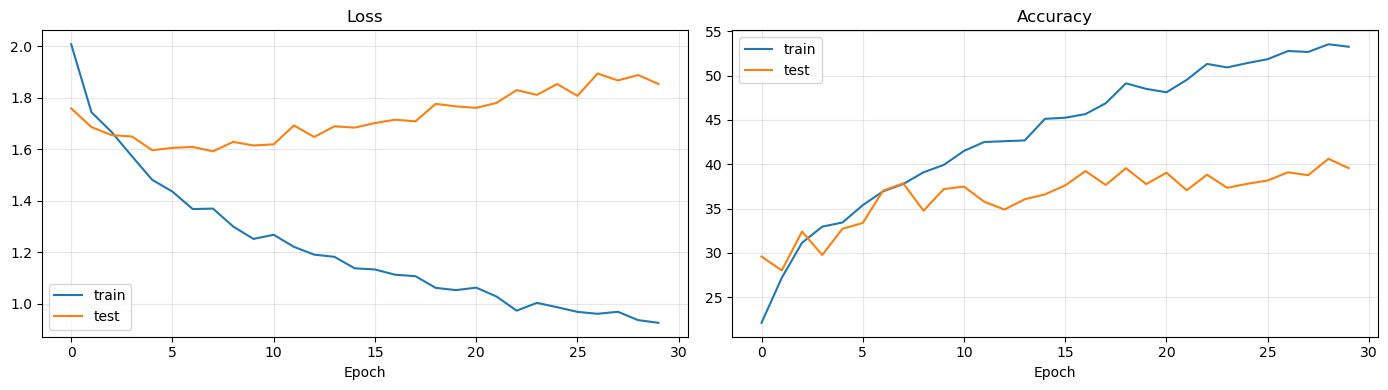

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["test_loss"], label="test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["test_acc"], label="test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Test accuracy: 39.55%
Test loss: 1.8535

              precision    recall  f1-score   support

       angry       0.31      0.62      0.42       197
     excited       0.53      0.38      0.44       459
        fear       0.08      0.17      0.11        30
  frustrated       0.52      0.22      0.30       611
       happy       0.25      0.40      0.31       154
     neutral       0.43      0.46      0.45       386
         sad       0.43      0.55      0.48       311
    surprise       0.16      0.68      0.26        19

    accuracy                           0.40      2167
   macro avg       0.34      0.44      0.35      2167
weighted avg       0.45      0.40      0.39      2167



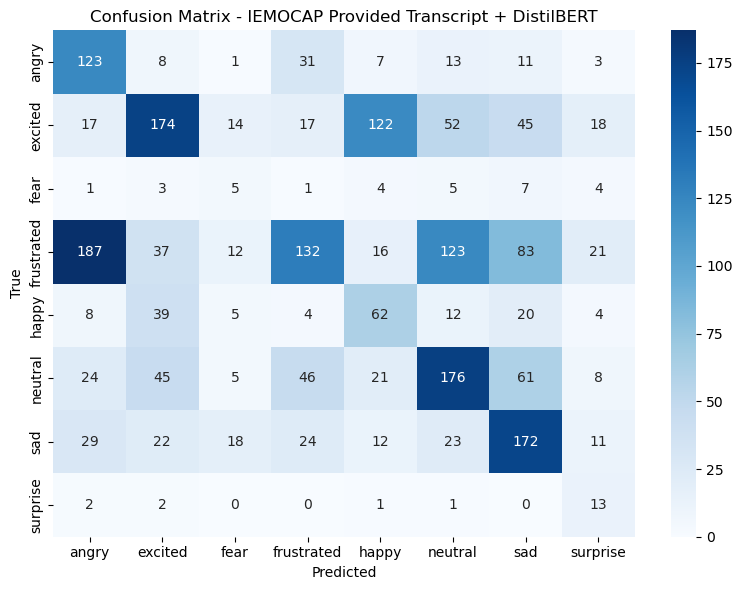

In [11]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
test_loss, test_acc, all_preds, all_labels = evaluate_model(model, test_loader, criterion, device)

print(f"Test accuracy: {test_acc:.2f}%")
print(f"Test loss: {test_loss:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=label_names, zero_division=0))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix - IEMOCAP Provided Transcript + DistilBERT")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## Save Checkpoint

In [12]:
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "label_names": label_names,
        "label_to_idx": label_to_idx,
        "idx_to_label": idx_to_label,
        "scaler_mean": scaler.mean_,
        "scaler_scale": scaler.scale_,
        "config": {
            "dataset_id": DATASET_ID,
            "label_column": LABEL_COLUMN,
            "drop_labels": sorted(DROP_LABELS),
            "min_samples_per_class": MIN_SAMPLES_PER_CLASS,
            "test_sessions": list(TEST_SESSIONS),
            "text_model_name": TEXT_MODEL_NAME,
        },
        "history": history,
    },
    CHECKPOINT_PATH,
)
print(f"Saved checkpoint to: {CHECKPOINT_PATH}")

Saved checkpoint to: models/IEMOCAP_transcript_distilbert.pth
